In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chinm\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
file_path = '../data/consumer_complaints_sample_balanced.csv'
df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


✅ Dataset loaded successfully!
Shape: (20000, 3)


,product,complaint_text,label
0,Consumer Loan,I reached an agreement with Universal Acceptan...,2
1,Credit reporting or other personal consumer re...,This is a formal complaint that Equifax is bei...,0
2,Debt collection,RECEIVABLE RECOVERY XXXX XXXX XXXX XXXX XXXX X...,1
3,Credit reporting or other personal consumer re...,I lodged a complaint with these Bureaus a mont...,0
4,Consumer Loan,Please see the attached document with the full...,2


Column names: ['product', 'complaint_text', 'label']

Label distribution:
label
2    5000
0    5000
1    5000
3    5000
Name: count, dtype: int64


c:\Users\chinm\OneDrive\Desktop\Desktop\project\Kaiburr\Chinmay\kaiburr-text-classification\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


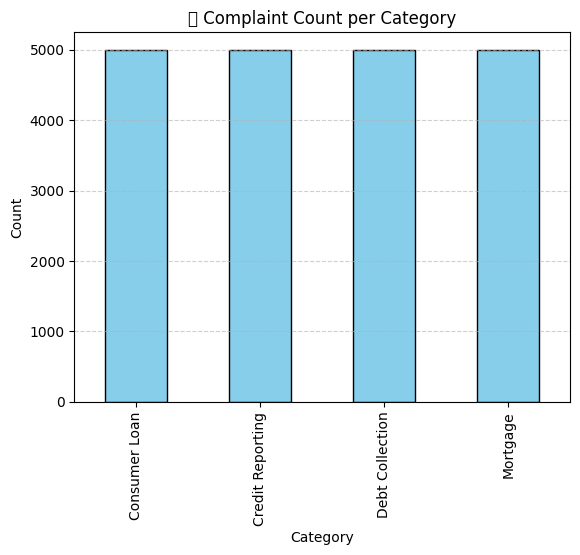

In [4]:
print("Column names:", df.columns.tolist())
print("\nLabel distribution:")
print(df['label'].value_counts())

# Map labels for readability
label_names = {
    0: 'Credit Reporting',
    1: 'Debt Collection',
    2: 'Consumer Loan',
    3: 'Mortgage'
}
df['category'] = df['label'].map(label_names)

df['category'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("📊 Complaint Count per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


C:\Users\chinm\AppData\Local\Temp\ipykernel_27072\2961675525.py:10: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\chinm\OneDrive\Desktop\Desktop\project\Kaiburr\Chinmay\kaiburr-text-classification\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


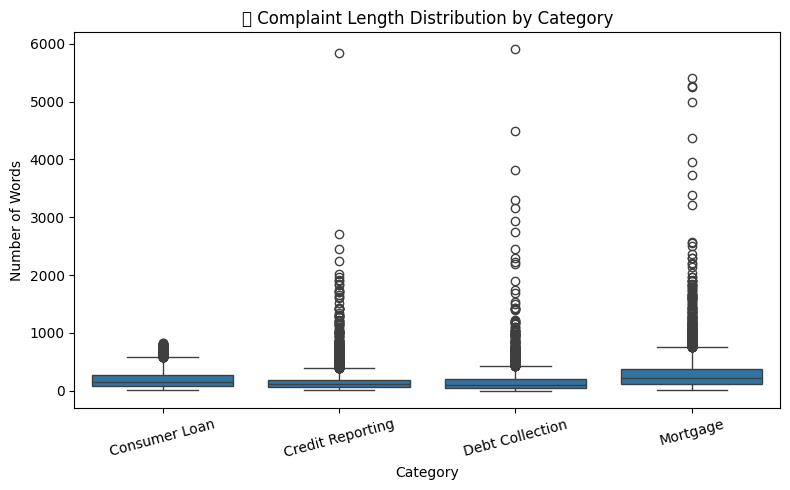

count    20000.00000
mean       208.41215
std        245.47951
min          1.00000
25%         71.00000
50%        140.00000
75%        264.00000
max       5905.00000
Name: text_length, dtype: float64


In [5]:
# Calculate text length for each complaint
df['text_length'] = df['complaint_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.boxplot(x='category', y='text_length', data=df)
plt.title("📝 Complaint Length Distribution by Category")
plt.ylabel("Number of Words")
plt.xlabel("Category")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(df['text_length'].describe())


In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    words = [w.lower() for w in text.split() if w.lower() not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['complaint_text'].apply(clean_text)


C:\Users\chinm\AppData\Local\Temp\ipykernel_27072\1365431896.py:11: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\chinm\OneDrive\Desktop\Desktop\project\Kaiburr\Chinmay\kaiburr-text-classification\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


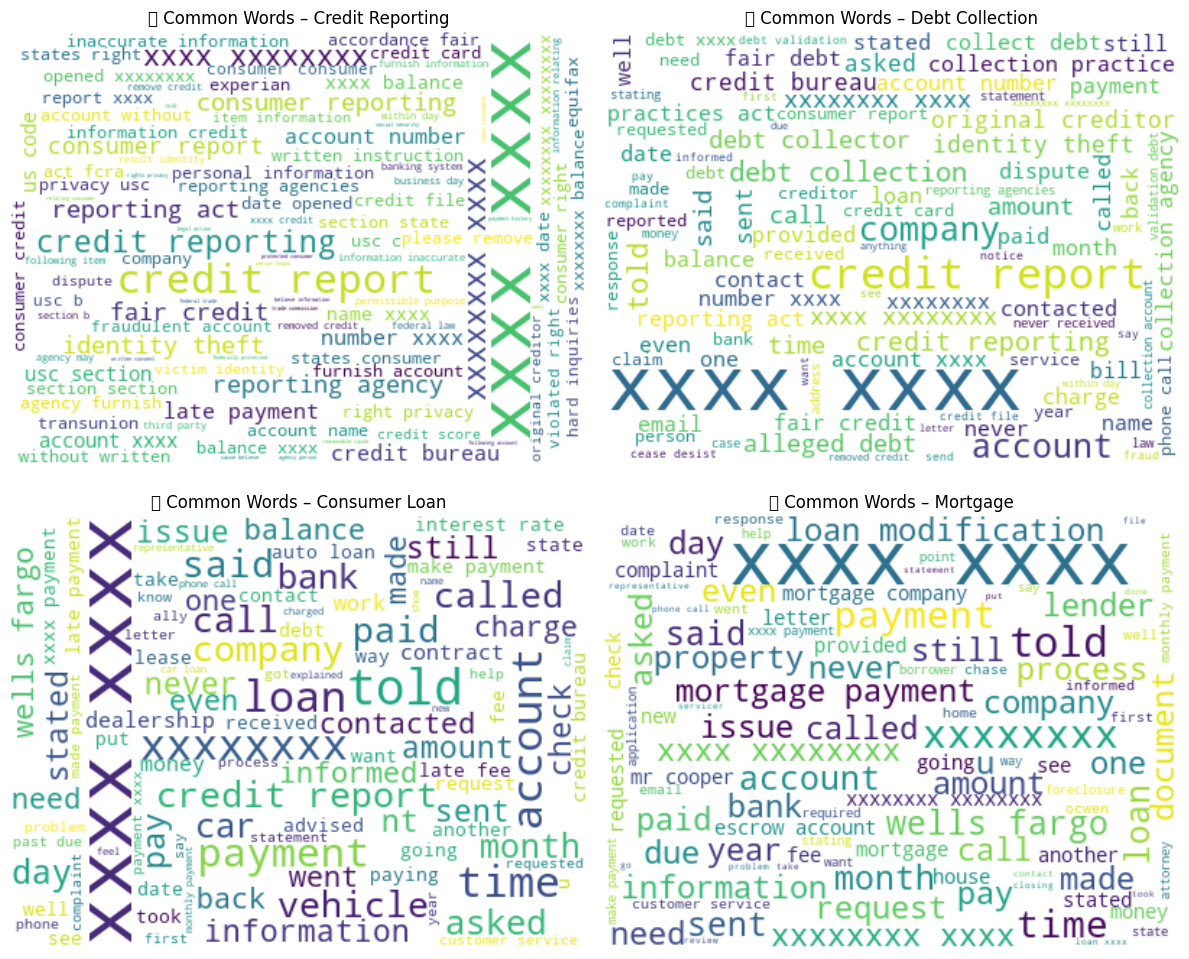

In [7]:
plt.figure(figsize=(12, 10))

for i, label in enumerate(label_names.keys()):
    plt.subplot(2, 2, i+1)
    text = " ".join(df[df['label'] == label]['clean_text'])
    wordcloud = WordCloud(width=400, height=300, background_color='white', max_words=100).generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"🌀 Common Words – {label_names[label]}")

plt.tight_layout()
plt.show()


c:\Users\chinm\OneDrive\Desktop\Desktop\project\Kaiburr\Chinmay\kaiburr-text-classification\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


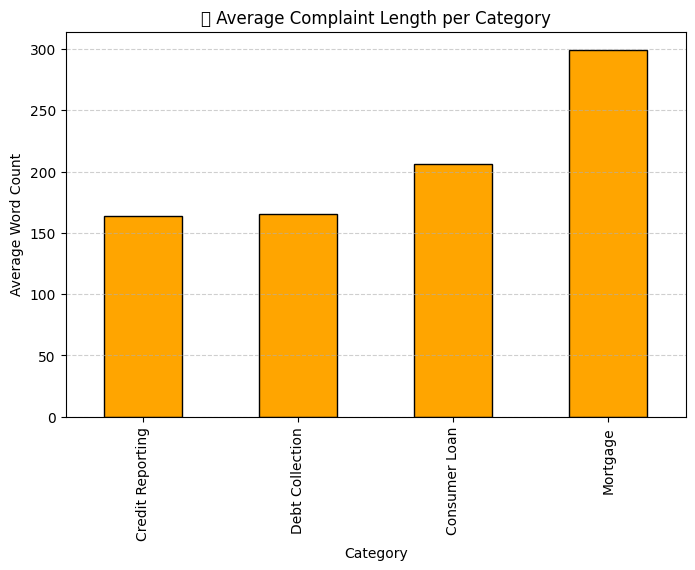

category
Credit Reporting    163.3712
Debt Collection     165.2400
Consumer Loan       205.8908
Mortgage            299.1466
Name: text_length, dtype: float64

In [8]:
avg_length = df.groupby('category')['text_length'].mean().sort_values()

plt.figure(figsize=(8,5))
avg_length.plot(kind='bar', color='orange', edgecolor='black')
plt.title("📏 Average Complaint Length per Category")
plt.ylabel("Average Word Count")
plt.xlabel("Category")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

avg_length


In [9]:
from collections import Counter

def top_words(label, n=10):
    words = " ".join(df[df['label'] == label]['clean_text']).split()
    return pd.DataFrame(Counter(words).most_common(n), columns=['word', 'count'])

for label in label_names:
    print(f"\n🔹 Top words in {label_names[label]} complaints:")
    display(top_words(label))



🔹 Top words in Credit Reporting complaints:


,word,count
0,xxxx,78839
1,credit,12239
2,report,8144
3,information,7502
4,account,7160
5,reporting,6495
6,consumer,6225
7,xxxxxxxx,5260
8,accounts,4057
9,usc,3416



🔹 Top words in Debt Collection complaints:


,word,count
0,xxxx,37750
1,debt,9444
2,credit,7679
3,account,5518
4,report,4349
5,information,3748
6,collection,3686
7,xxxxxxxx,3493
8,company,2875
9,reporting,2516



🔹 Top words in Consumer Loan complaints:


,word,count
0,xxxx,35476
1,loan,7043
2,payment,6646
3,credit,6257
4,car,4975
5,would,4617
6,account,4373
7,payments,3746
8,told,3730
9,xxxxxxxx,3438



🔹 Top words in Mortgage complaints:


,word,count
0,xxxx,59627
1,mortgage,11158
2,xxxxxxxx,10902
3,loan,10565
4,payment,8376
5,would,5912
6,payments,4658
7,account,4632
8,told,4436
9,home,4392
